# Creación del primer modelo (drafteado sí o no/ronda)

Importo librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

Cargo el dataset anteriormente trabajado

In [2]:
ncaa = pd.read_csv('../datos/procesados/ncaa_final.csv')

Miro la información y métricas importantes del dataset

In [3]:
ncaa.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   GP                         2121 non-null   int64  
 1   Min_per                    2121 non-null   float64
 2   Ortg                       2121 non-null   float64
 3   usg                        2121 non-null   float64
 4   eFG                        2121 non-null   float64
 5   TS_per                     2121 non-null   float64
 6   ORB_per                    2121 non-null   float64
 7   DRB_per                    2121 non-null   float64
 8   AST_per                    2121 non-null   float64
 9   TO_per                     2121 non-null   float64
 10  FT_per                     2121 non-null   float64
 11  twoP_per                   2121 non-null   float64
 12  TP_per                     2121 non-null   float64
 13  blk_per                    2121 non-null   float64
 14  stl

## Empiezo con el modelo para predecir si un jugador será drafteado y en qué ronda

Miro la distribución de la target

In [4]:
ncaa['ronda'].value_counts(normalize=True)

ronda
ND    0.707214
R1    0.151815
R2    0.140971
Name: proportion, dtype: float64

Respecto a la variable a predecir, ronda, se ve un claro desbalanceo. Esto es normal, dado que ser elegido en primera o segunda ronda para los jugadores de la NCAA es lo menos habitual. La excepción es ser elegido y poder tener la oportunidad en la NBA. 

Creo la el dataframe X (Variables predictoras) y el dataframe y (target)

In [5]:
# separo variables y target

X = ncaa.drop(columns=['ronda', 'rango_pick'])
y = ncaa['ronda']

# transformo la variable 'posicion' a numérica
X = pd.get_dummies(X, columns=['posicion'], drop_first=False)

# transformo el target a numérico con LabelEncoder
le_target_draft = LabelEncoder()
y_enc = le_target_draft.fit_transform(y)  # ND=0, R1=1, R2=2

print("Clases:", le_target_draft.classes_)
print("Distribución:", pd.Series(y_enc).value_counts(normalize=True).round(3))


Clases: ['ND' 'R1' 'R2']
Distribución: 0    0.707
1    0.152
2    0.141
Name: proportion, dtype: float64


Divido los datos en entrenamiento y test. 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, # incluyo las variables transformadas
    test_size=0.15, # tamaño del test
    random_state=11, #semilla
    stratify=y_enc # mantengo la proporción de clases
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(1802, 43)
(319, 43)
(1802,)
(319,)


Aquí hay que pensar en cuál será el primer modelo que probaré. Dado que hay muchas estadísticas, un desbalanceo de clases y que tengo más de 30 variables, parece que el que más sentido tiene utilizar es el XGBClassifier.

Entreno los datos con el XGBClassifier (clasificación multiclase). Usamos parámetros sencillos como punto de partida.

In [7]:
# defino el modelo con parámetros básicos
modelo = XGBClassifier(
    objective='multi:softmax', # devuelve directamente la clase ganadora
    num_class=3, # número de clases
    n_estimators=100, # número de árboles
    max_depth=4, # profundidad máxima de cada árbol
    learning_rate=0.1, # tasa de aprendizaje
    random_state=11, # semilla
    eval_metric='mlogloss' # métrica de evaluación (penaliza más los errores en los que 
                           # el modelo estaba muy seguro y se equivocó. Si el modelo dice "99% de que es ND"
                           # y resulta ser R1, el castigo es enorme. Si dice "55% ND" y falla, el castigo es pequeño)
)

# entreno el modelo
modelo.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

Evalúo el modelo con el conjunto de test usando el classification report y la matriz de confusión.

In [8]:
y_pred = modelo.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le_target_draft.classes_))


              precision    recall  f1-score   support

          ND       0.85      0.95      0.89       226
          R1       0.49      0.40      0.44        48
          R2       0.67      0.40      0.50        45

    accuracy                           0.79       319
   macro avg       0.67      0.58      0.61       319
weighted avg       0.77      0.79      0.77       319



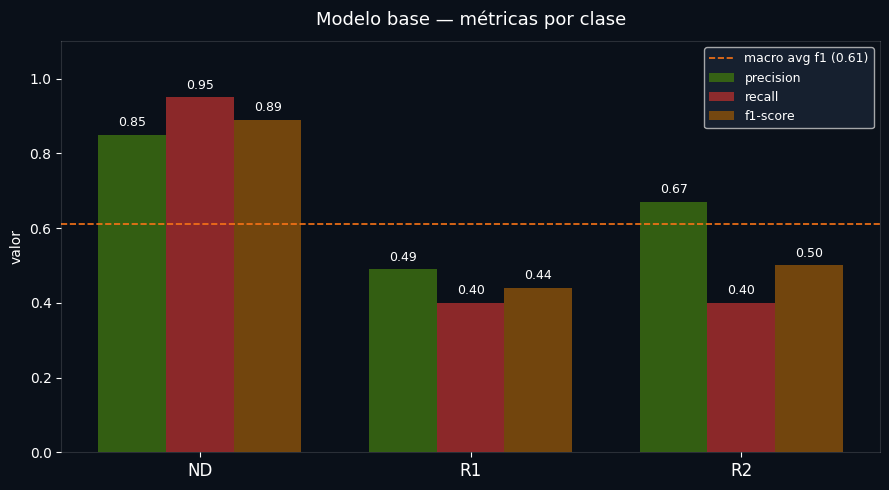

In [9]:
# datos del classification report
clases = ['ND', 'R1', 'R2']
precision = [0.85, 0.49, 0.67]
recall    = [0.95, 0.40, 0.40]
f1        = [0.89, 0.44, 0.50]

metricas = {'precision': precision, 'recall': recall, 'f1-score': f1}
colores  = ['#3B6D11', '#A32D2D', '#854F0B']  # verde, rojo, naranja

x = np.arange(len(clases))
ancho = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0a1019')
ax.set_facecolor('#0a1019')

for i, (nombre, valores) in enumerate(metricas.items()):
    barras = ax.bar(x + i * ancho, valores, ancho, label=nombre, color=colores[i], alpha=0.85)
    for barra in barras:
        alto = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            alto + 0.015,
            f'{alto:.2f}',
            ha='center', va='bottom',
            fontsize=9, color='white'
        )

# linea de referencia macro avg f1
ax.axhline(y=0.61, color='#f97316', linestyle='--', linewidth=1.2, label='macro avg f1 (0.61)')

ax.set_xticks(x + ancho)
ax.set_xticklabels(clases, color='white', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('valor', color='white')
ax.set_title('Modelo base — métricas por clase', color='white', fontsize=13, pad=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a2535', labelcolor='white', fontsize=9)

for spine in ax.spines.values():
    spine.set_edgecolor('#ffffff22')

plt.tight_layout()

El test que utilizo para evaluar el modelo tiene 319 jugadores. En la evaluación, el modelo mira las estadísticas y predice si no será drafteado, si lo será en primera ronda o en segunda ronda. ¿Cómo se evalúa? Comparando lo que dijo el modelo con la realidad.

Con la métrica PRECISION, en el caso de R1, el modelo señaló a algunos jugadores como R1 y de esos, solo el 49 % era R1 de verdad. Sin embargo, con ND fue el 85 % y con R2 fue del 67 %.

RECALL nos muestra "de los que había, ¿cuántos encontró?". Por ejemplo, había 48 jugadores reales de R1 en el test y el modelo solo encontró el 40 % de ellos. En el caso de ND, encontró el 95 % y en el caso de R2 encontró el 40 %.

La combinación de las anteriores métricas es F1 Score. En realidad, seguimos viendo que la predicción de la R1 y la R2 no es para nada buena, ya que están por debajo del 50 % (moneda al aire).

Por último, se representa el macro avg f1, nota media de las tres métricas. Aquí se trata las tres clases por igual, sin importar cuántos jugadores hay en cada una. Es la foto real del modelo. Y en este caso no es que sea bueno.

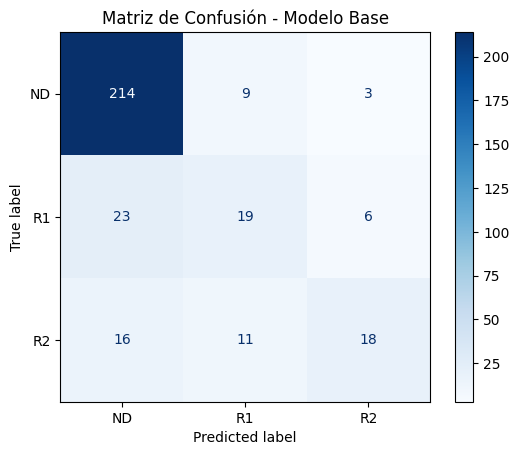

In [45]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target_draft.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Modelo Base')
plt.show()

* FILA ND — jugadores que realmente NO fueron drafteados (había 226 en total)

    * 214 → dijo ND ✅ acertó
    * 9 → dijo R1 ❌ falso positivo de R1 — el modelo se inventó un talento que no existía
    * 3 → dijo R2 ❌ falso positivo de R2 — igual

    El modelo es muy bueno aquí. Casi no falla con los no drafteados.

* FILA R1 — jugadores que realmente fueron a primera ronda (había 48 en total)

    * 19 → dijo R1 ✅ acertó
    * 23 → dijo ND ❌ falso negativo — se perdió 23 joyas de primera ronda
    * 6 → dijo R2 ❌ los confundió con segunda ronda

    De 48 jugadores de primera ronda, solo encontró 19. Los otros 29 los mandó a ND o R2 sin más.

* FILA R2 — jugadores que realmente fueron a segunda ronda (había 45 en total)

    * 18 → dijo R2 ✅ acertó
    * 16 → dijo ND ❌ falso negativo — se perdió 16 jugadores de segunda ronda
    * 11 → dijo R1 ❌ los confundió con primera ronda


* Resumen en una frase:

    El modelo se podría definir como cobarde, ya que cuando duda, siempre dice "este no vale". Por eso se pierde a 39 jugadores drafteados reales (23 de R1 + 16 de R2) mandándolos a ND. Esos 39 son los falsos negativos que hay que reducir en el modelo final.


Estoy viendo que este modelo penaliza poco los errores en R1 y R2, porque son minoría. Por tanto, buscaré calcular pesos por clase para que el modelo preste más atención a los jugadores drafteados.


              precision    recall  f1-score   support

          ND       0.94      0.84      0.88       226
          R1       0.41      0.50      0.45        48
          R2       0.38      0.49      0.43        45

    accuracy                           0.74       319
   macro avg       0.57      0.61      0.59       319
weighted avg       0.78      0.74      0.75       319



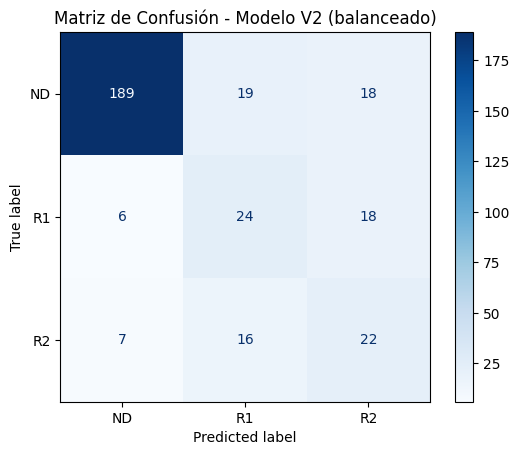

In [10]:
from sklearn.utils.class_weight import compute_sample_weight

# calculo pesos para cada muestra según la clase a la que pertenece
pesos = compute_sample_weight(class_weight='balanced', y=y_train)

# defino un nuevo modelo con los mismos parámetros pero usando los pesos
modelo_v2_XGBC = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

# entreno el modelo con los pesos
modelo_v2_XGBC.fit(X_train, y_train, sample_weight=pesos)

# hago predicciones con el nuevo modelo
y_pred_v2 = modelo_v2_XGBC.predict(X_test)

# evalúo el nuevo modelo
print(classification_report(y_test, y_pred_v2, target_names=le_target_draft.classes_))

# matriz de confusión para el nuevo modelo
cm2 = confusion_matrix(y_test, y_pred_v2)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=le_target_draft.classes_)
disp2.plot(cmap='Blues')
plt.title('Matriz de Confusión - Modelo V2 (balanceado)')
plt.show()


El modelo base es más "cobarde" — predice ND casi siempre y parece bueno. El V2 es más valiente pero se equivoca más. Ninguno es bueno todavía detectando R1 y R2, que es justo lo que más nos interesa predecir.

## Evaluación con AUC-ROC

El **AUC-ROC** mide qué tan bien separa el modelo cada clase del resto. 

Para clasificación multiclase usamos **One vs Rest (OvR)**: por cada clase, el modelo compite contra todas las demás. El resultado es un valor entre 0 y 1 por clase:
- **1.0** → separación perfecta
- **0.5** → equivale a adivinar al azar
- **Por debajo de 0.5** → el modelo lo hace peor que el azar

Usamos `predict_proba` para obtener probabilidades en vez de clases directas — el AUC-ROC necesita probabilidades para funcionar.

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# binarizo el test para poder calcular AUC-ROC por clase (One vs Rest)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# obtengo probabilidades del modelo v2
probs_v2 = modelo_v2_XGBC.predict_proba(X_test)

# calculo AUC-ROC macro (media de las 3 clases)
auc_macro = roc_auc_score(y_test_bin, probs_v2, multi_class='ovr', average='macro')
print(f'AUC-ROC macro: {auc_macro:.4f}')
print()

# calculo y pinto la curva ROC de cada clase
fig, ax = plt.subplots(figsize=(8, 6))
colores = ['#3B6D11', '#A32D2D', '#854F0B']

for i, (clase, color) in enumerate(zip(le_target_draft.classes_, colores)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_v2[:, i])
    auc = roc_auc_score(y_test_bin[:, i], probs_v2[:, i])
    ax.plot(fpr, tpr, color=color, label=f'{clase} (AUC = {auc:.3f})')

# línea diagonal = modelo aleatorio
ax.plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC por clase — modelo v2 XGBoost')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Guardo el modelo mejorado y el encoder de la target para poder reutilizarlos.


In [11]:
os.makedirs('../pkl/modelos', exist_ok=True)
os.makedirs('../pkl/preprocesado', exist_ok=True)

joblib.dump(modelo_v2_XGBC, '../pkl/modelos/xgb_draft_balanceado.pkl')
joblib.dump(le_target_draft, '../pkl/preprocesado/le_target_draft.pkl')

print("Modelo guardado")


Modelo guardado


Hago una predicción a ver qué sucede. Busco un jugador por nombre en el dataset raw, lo cruzo con los datos procesados 
y predigo con el modelo entrenado. Uso `predict_proba` para obtener probabilidades.


In [13]:
raw = pd.read_csv('../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)
ncaa_final = pd.read_csv('../datos/procesados/ncaa_final.csv')

# cambiar aquí el nombre del jugador
jugador_nombre = 'Cade Cunningham'
jugador_raw = raw[raw['player_name'] == jugador_nombre].iloc[0]

# buscar su fila en los datos procesados por stats únicas
mask = (
    (ncaa_final['pts'].round(4) == round(jugador_raw['pts'], 4)) &
    (ncaa_final['treb'].round(4) == round(jugador_raw['treb'], 4)) &
    (ncaa_final['ast'].round(4) == round(jugador_raw['ast'], 4))
)
jugador_procesado = ncaa_final[mask]

# Preparar variables igual que en el modelo
X_jugador = jugador_procesado.drop(columns=['ronda', 'rango_pick'])
X_jugador = pd.get_dummies(X_jugador, columns=['posicion'])
X_jugador = X_jugador.reindex(columns=X_train.columns, fill_value=0)

# predecir con probabilidades
probs = modelo_v2_XGBC.predict_proba(X_jugador)[0]

print(f"Predicción para {jugador_nombre} (Draft 2021):")
for clase, prob in zip(le_target_draft.classes_, probs):
    print(f"  {clase}: {prob*100:.1f}%")

# ronda real según su pick
pick = jugador_raw['pick']
ronda_real = 'R1' if pick <= 30 else ('R2' if pick <= 60 else 'ND')
print(f"\nRealidad: Pick #{int(pick)} → {ronda_real}")


Predicción para Cade Cunningham (Draft 2021):
  ND: 10.6%
  R1: 65.7%
  R2: 23.6%

Realidad: Pick #1 → R1


Pruebo con un jugador elegido en segunda ronda.

In [14]:
r2_2021 = raw[
    (raw['year'] == 2021) & 
    (raw['pick'].notna()) & 
    (raw['pick'] >= 31) & 
    (raw['pick'] <= 60)
]
print(r2_2021[['player_name', 'pick', 'pts', 'treb', 'ast']].sort_values('pick'))


                  player_name  pick      pts     treb     ast
59286  Jeremiah Robinson-Earl  32.0  15.7200   8.4800  2.2000
57211           Jason Preston  33.0  15.7000   7.2500  7.2500
56945           Herbert Jones  35.0  11.2424   6.5758  3.2727
59129           Miles McBride  36.0  15.7931   3.8966  4.8621
60358                 JT Thor  37.0   9.3704   5.0370  0.8519
57665             Ayo Dosunmu  38.0  20.1429   6.3214  5.2500
57904           Neemias Queta  39.0  14.9310  10.1379  2.6552
57469            Jared Butler  40.0  16.7333   3.3000  4.8000
57713            Joe Wieskamp  41.0  14.8387   6.6129  1.7097
56447           Isaiah Livers  42.0  13.0870   6.0000  2.0000
60714          Greg Brown III  43.0   9.3462   6.1538  0.3846
57661         Kessler Edwards  44.0  17.2222   6.8148  1.2222
57276           Dalano Banton  46.0   9.5556   5.8889  3.8889
58253           David Johnson  47.0  12.6316   5.7895  3.2105
59982          Sharife Cooper  48.0  20.1667   4.2500  8.0833
57079   

Predigo la ronda de Luka Garza y su realidad según su pick

In [15]:
raw = pd.read_csv('../datos/raw/College_BasketballPlayers2009-2021.csv', low_memory=False)
ncaa_final = pd.read_csv('../datos/procesados/ncaa_final.csv')

jugador_nombre = 'Luka Garza'
jugador_raw = raw[(raw['player_name'] == jugador_nombre) & (raw['year'] == 2021)].iloc[0]

mask = (
    (ncaa_final['pts'].round(4) == round(jugador_raw['pts'], 4)) &
    (ncaa_final['treb'].round(4) == round(jugador_raw['treb'], 4)) &
    (ncaa_final['ast'].round(4) == round(jugador_raw['ast'], 4))
)
jugador_procesado = ncaa_final[mask]

X_jugador = jugador_procesado.drop(columns=['ronda', 'rango_pick'])
X_jugador = pd.get_dummies(X_jugador, columns=['posicion'])
X_jugador = X_jugador.reindex(columns=X_train.columns, fill_value=0)

probs = modelo_v2_XGBC.predict_proba(X_jugador)[0]

print(f"Predicción para {jugador_nombre} (Draft 2021):")
for clase, prob in zip(le_target_draft.classes_, probs):
    print(f"  {clase}: {prob*100:.1f}%")

pick = jugador_raw['pick']
ronda_real = 'R1' if pick <= 30 else ('R2' if pick <= 60 else 'ND')
print(f"\nRealidad: Pick #{int(pick)} → {ronda_real}")


Predicción para Luka Garza (Draft 2021):
  ND: 6.5%
  R1: 14.7%
  R2: 78.9%

Realidad: Pick #52 → R2


Pero, ¿qué pasaría si metemos el nombre de una persona y sus estadísticas de manera manual?

In [16]:
nombre_jugador = 'Roberto Cantero'

pts  = 18.9
treb = 7.7
ast  = 5.9

# construyo el dataframe base con todas las columnas del modelo a 0
X_manual = pd.DataFrame(0, index=[0], columns=X_train.columns)

# relleno solo las tres stats
X_manual['pts']  = pts
X_manual['treb'] = treb
X_manual['ast']  = ast

# predicción
probs = modelo_v2_XGBC.predict_proba(X_manual)[0]

print(f"\n Predicción manual para {nombre_jugador}")
for clase, prob in zip(le_target_draft.classes_, probs):
    print(f"  {clase:>3}  {prob*100:5.1f}%")


 Predicción manual para Roberto Cantero
   ND    4.0%
   R1   40.8%
   R2   55.2%
